# R02 — [Rebuttal] Eight-Task Constellations & Per-Task OR Directions

**Reviewer concern addressed:** the paper's per-task over-refusal direction analysis rests on
**two** tasks (sentiment analysis, translation). With the four new tasks from **R01**
(`pos_tagging`, `word_shuffle`, `char_shuffle`, `conversational_qa`) we re-run every geometric claim on the
**combined 8-task set**:

| # | Claim (paper §) | Re-test here |
|---|---|---|
| 1 | Task-identity constellations dominate mid-layers (§4.2, Fig. 3–4) | 8-task inter-task silhouette curve + galaxy PCA |
| 2 | Per-task OR directions diverge (§4.2, Fig. 5) | Pairwise cosine over **all** tasks with OR n≥5 (was: 2) |
| 3 | OR direction ≠ Arditi direction (§4.2, Fig. 4) | cos(OR, Arditi) per layer with the enlarged OR set |
| 4 | OR spans a higher-dimensional subspace (§4.2, Fig. 6) | n₈₀ with the enlarged, more task-diverse OR set |

**Inputs:** original memory bank (`./embeddings/`), R01 outputs (`./rebuttal_embeddings/`),
`arditi_artefacts/` from NB8. **Compute:** CPU only.

All headline numbers print with `[R2.x]` tags that map to placeholders in the rebuttal markdowns.


In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 13, 'font.family': 'serif',
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False,
    'axes.spines.right': False, 'lines.linewidth': 2.2,
})

TASK_COLORS = {
    'sentiment_analysis': '#E74C3C', 'translate':         '#3498DB',
    'rephrase':           '#F39C12', 'rag_qa':            '#27AE60',
    'cryptanalysis':      '#9B59B6', 'pos_tagging':        '#16A085',
    'word_shuffle':       '#D35400', 'char_shuffle':       '#7F8C8D',
    'conversational_qa':  '#C0392B',   # largest OR task in the study -- give it a distinct color
}
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)
print('Setup complete')


Setup complete


## Load and merge the two memory banks

The original 270-sample bank (5 tasks) and the R01 bank (4 new tasks) share the same layer
keys (`layer_i_input_norm`) and label schema, so they concatenate directly.


In [2]:
## If on Colab, copy artefacts first (mirrors NB14):
from google.colab import drive; drive.mount('/content/drive')
!mkdir -p embeddings rebuttal_embeddings arditi_artefacts
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/llama/." ./embeddings/.
!cp -a "/content/drive/MyDrive/embeddings/overalign_eval/rebuttal/." ./rebuttal_embeddings/.
!cp -a "/content/drive/MyDrive/Colab Notebooks/SteeringFail/arditi_artefacts/." ./arditi_artefacts/.

def load_bank(emb_dir):
    """Load a NB4-schema memory bank (CSV + .pt) from a directory."""
    csvs = sorted(f for f in os.listdir(emb_dir) if f.endswith('.csv'))
    assert csvs, f'no CSV found in {emb_dir}'
    if len(csvs) > 1:
        print(f'  [load_bank {emb_dir}] WARNING: {len(csvs)} CSVs found: {csvs}')
        print(f'  [load_bank {emb_dir}] picking (sorted-last): {csvs[-1]} -- verify this is intended!')
    csv_df = pd.read_csv(os.path.join(emb_dir, csvs[-1]))
    REQUIRED_COLS = ['refusal_class', 'llm_evaluation', 'torch_path']
    missing = [c for c in REQUIRED_COLS if c not in csv_df.columns]
    if missing:
        raise ValueError(
            f"{emb_dir}: latest CSV ({csvs[-1]}) is missing columns {missing}. "
            "This usually means the CSV was persisted to Drive BEFORE the GPT-4o judging "
            "step ran in R01 (Step 3's save happens before Step 4's judging updates the "
            "same file). Fix: go back to the R01 session, re-run its Drive-persist cell "
            "(now at the END of Step 4, after judging), then re-copy from Drive here.")
    print(f'  [load_bank {emb_dir}] loaded {csvs[-1]}: {len(csv_df)} rows')
    task_col = 'intended_task' if 'intended_task' in csv_df.columns else None
    if task_col:
        print(csv_df.value_counts([task_col, 'refusal_class']).to_string())
    pt_candidates = [csv_df['torch_path'].iloc[0],
                     os.path.join(emb_dir, os.path.basename(csv_df['torch_path'].iloc[0]))]
    pt_path = next(p for p in pt_candidates if os.path.exists(p))
    t = torch.load(pt_path, map_location='cpu', weights_only=False)
    emb = {}
    for k, v in t['embeddings'].items():
        if isinstance(v, torch.Tensor):
            emb[k] = v.float().numpy().astype(np.float32)
        else:
            emb[k] = np.array([e.float().numpy().astype(np.float32) for e in v])
    return emb, t, csv_df

emb_o, t_o, csv_o = load_bank('./embeddings')          # original 270
emb_r, t_r, csv_r = load_bank('./rebuttal_embeddings') # R01 new tasks

SHARED_LAYERS = [k for k in emb_o if k in emb_r and k.startswith('layer_')]
SHARED_LAYERS.sort(key=lambda k: int(k.split('_')[1]))
LAYER_NUMS = [int(k.split('_')[1]) for k in SHARED_LAYERS]

embeddings_np = {k: np.vstack([emb_o[k], emb_r[k]]) for k in SHARED_LAYERS}
n_o, n_r = emb_o[SHARED_LAYERS[0]].shape[0], emb_r[SHARED_LAYERS[0]].shape[0]

intended_task_labels = np.concatenate([np.array(t_o['intended_task_labels']),
                                       np.array(t_r['intended_task_labels'])])
text_type_labels     = np.concatenate([np.array(t_o['text_type_labels']),
                                       np.array(t_r['text_type_labels'])])
refusal_labels       = np.concatenate([csv_o['refusal_class'].values,
                                       csv_r['refusal_class'].values])
response_labels      = np.concatenate([csv_o['llm_evaluation'].values,
                                       csv_r['llm_evaluation'].values])
origin               = np.array(['original'] * n_o + ['rebuttal'] * n_r)

print(f'Merged: {n_o} original + {n_r} new = {n_o + n_r} samples | {len(SHARED_LAYERS)} shared layers')
print('Tasks:', sorted(np.unique(intended_task_labels)))


Mounted at /content/drive
  [load_bank ./embeddings] loaded overalign_eval_Meta-Llama-3.1-8B-Instruct_20250714_082134.csv: 270 rows
intended_task       refusal_class   
cryptanalysis       direct_answer       60
rephrase            direct_answer       39
sentiment_analysis  direct_answer       35
translate           direct_answer       32
rag_qa              direct_answer       30
translate           direct_refusal      24
rephrase            direct_refusal      24
sentiment_analysis  direct_refusal      17
translate           indirect_refusal     4
sentiment_analysis  indirect_refusal     3
rephrase            indirect_refusal     2
  [load_bank ./rebuttal_embeddings] loaded rebuttal_newtasks_Meta-Llama-3.1-8B-Instruct_20260708_190808.csv: 820 rows
intended_task      refusal_class   
word_shuffle       direct_answer       203
pos_tagging        direct_answer       202
char_shuffle       direct_answer       197
conversational_qa  direct_answer       112
                   indirect_refu

In [3]:
# ── Masks (identical definitions to NB14 §Setup, benign set extended) ─────────
REFUSING_MASK = np.isin(refusal_labels, ['direct_refusal', 'indirect_refusal'])
ANSWERED_MASK = refusal_labels == 'direct_answer'
HARMFUL_MASK  = text_type_labels == 'harmful_instruction'

BENIGN_TASKS  = ['sentiment_analysis', 'translate', 'cryptanalysis', 'rag_qa',
                 'pos_tagging', 'word_shuffle', 'char_shuffle', 'conversational_qa']
# NOTE: this whitelist must be updated whenever R01 adds a new task frame. It intentionally
# excludes 'rephrase' (can itself constitute a harmful instruction per the paper's Table
# dataset, so a refusal there may be correct, not over-refusal) -- it is NOT simply
# "~HARMFUL_MASK", which is why this is a maintained list rather than a text_type check.
BENIGN_MASK   = np.isin(intended_task_labels, BENIGN_TASKS) & ~HARMFUL_MASK

TARGET_MASK       = np.isin(response_labels, ['cautious', 'not_harmful']) & ANSWERED_MASK
OVER_REFUSAL_MASK = BENIGN_MASK & REFUSING_MASK
REFUSED_HARMFUL   = HARMFUL_MASK & REFUSING_MASK
HARMLESS_ANSWERED = BENIGN_MASK & ANSWERED_MASK

ALL_TASKS = sorted(np.unique(intended_task_labels))

print('=== SAMPLE COUNTS (8-task combined set) ===')
print(f'  Over-refusal:      {OVER_REFUSAL_MASK.sum():>4d}')
print(f'  Refused-harmful:   {REFUSED_HARMFUL.sum():>4d}')
print(f'  Harmless-answered: {HARMLESS_ANSWERED.sum():>4d}')
print()
print(f'{"task":<20} {"OR":>4} {"RH":>4} {"HA":>4}')
for task in ALL_TASKS:
    m = intended_task_labels == task
    print(f'{task:<20} {(m & OVER_REFUSAL_MASK).sum():>4d} '
          f'{(m & REFUSED_HARMFUL).sum():>4d} {(m & HARMLESS_ANSWERED).sum():>4d}')


=== SAMPLE COUNTS (8-task combined set) ===
  Over-refusal:       113
  Refused-harmful:     49
  Harmless-answered:  817

task                   OR   RH   HA
char_shuffle            3    5  183
conversational_qa      75   18  111
cryptanalysis           0    0   60
pos_tagging             3    0  183
rag_qa                  0    0   30
rephrase                0    8    0
sentiment_analysis     13    7   34
translate              18   10   31
word_shuffle            1    1  185


## Analysis 1 — Do task constellations survive 8 tasks?

If the mid-layer structure is genuine task identity, adding three tasks should preserve (or
sharpen) the inter-task silhouette. If the original 5-cluster structure was an artefact of a
lucky task selection, the 8-task silhouette should collapse.

Reference values (paper): LLaMA peak silhouette **0.454 @ L12** (5 tasks).


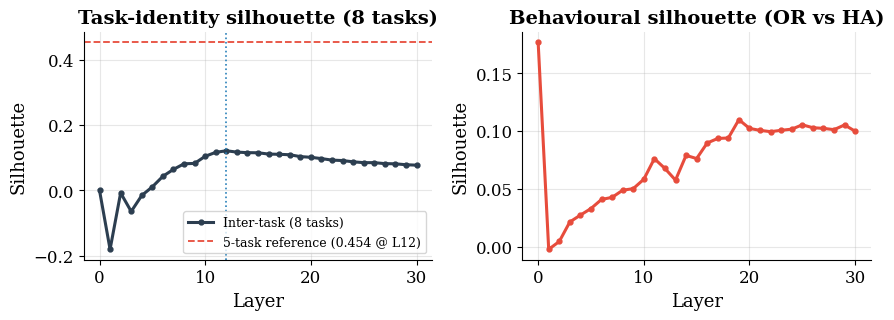

[R2.1] 8-task inter-task silhouette peak: 0.121 @ L12
[R2.2] 5-task reference:                  0.454 @ L12
[R2.3] Behavioural silhouette peak:       0.177 @ L0

Interpretation guide:
 - Peak within ~0.05 of 0.454 → constellation structure is robust to task count;
   say "the constellation structure is not an artefact of the original 5 tasks".
 - Notably higher → adding content-matched tasks sharpened separation (stronger claim).
 - Much lower (<0.30) → inspect the galaxy plot below: new tasks may overlap each
   other (e.g. the two shuffle tasks) while remaining separated from the original 5;
   report a merged-cluster variant if so.


In [4]:
from sklearn.metrics import silhouette_score

sil_8task, sil_behav = [], []
for lname in SHARED_LAYERS:
    X = embeddings_np[lname]
    sil_8task.append(silhouette_score(X, intended_task_labels))
    m = OVER_REFUSAL_MASK | HARMLESS_ANSWERED
    sil_behav.append(silhouette_score(X[m], OVER_REFUSAL_MASK[m].astype(int)))

sil_8task, sil_behav = np.array(sil_8task), np.array(sil_behav)
PEAK_IDX   = int(np.argmax(sil_8task))
PEAK_LAYER = SHARED_LAYERS[PEAK_IDX]
PEAK_NUM   = LAYER_NUMS[PEAK_IDX]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].plot(LAYER_NUMS, sil_8task, color='#2C3E50', marker='o', ms=3.5,
             label='Inter-task (8 tasks)')
axes[0].axhline(0.454, color='#E74C3C', ls='--', lw=1.3,
                label='5-task reference (0.454 @ L12)')
axes[0].axvline(PEAK_NUM, color='#2980B9', ls=':', lw=1.2)
axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Silhouette')
axes[0].set_title('Task-identity silhouette (8 tasks)')
axes[0].legend(fontsize=9)
axes[1].plot(LAYER_NUMS, sil_behav, color='#E74C3C', marker='o', ms=3.5)
axes[1].set_xlabel('Layer'); axes[1].set_ylabel('Silhouette')
axes[1].set_title('Behavioural silhouette (OR vs HA)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig02_silhouette_8task.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'[R2.1] 8-task inter-task silhouette peak: {sil_8task.max():.3f} @ L{PEAK_NUM}')
print(f'[R2.2] 5-task reference:                  0.454 @ L12')
print(f'[R2.3] Behavioural silhouette peak:       {sil_behav.max():.3f} '
      f'@ L{LAYER_NUMS[int(np.argmax(sil_behav))]}')
print()
print('Interpretation guide:')
print(' - Peak within ~0.05 of 0.454 → constellation structure is robust to task count;')
print('   say "the constellation structure is not an artefact of the original 5 tasks".')
print(' - Notably higher → adding content-matched tasks sharpened separation (stronger claim).')
print(' - Much lower (<0.30) → inspect the galaxy plot below: new tasks may overlap each')
print('   other (e.g. the two shuffle tasks) while remaining separated from the original 5;')
print('   report a merged-cluster variant if so.')


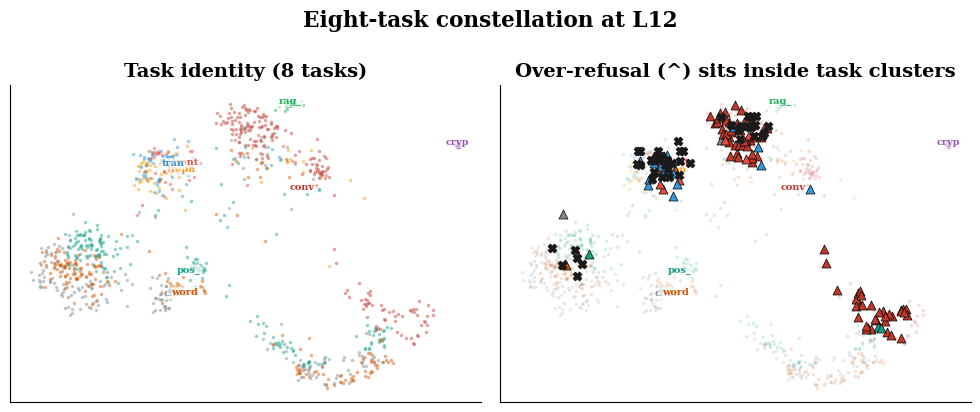

Check: do OR triangles of the NEW tasks also sit inside their own task clusters?
If yes → the "within-cluster perturbation" claim (paper Fig. 3) generalizes.


In [5]:
# ── Galaxy PCA at the peak layer, 8 tasks ─────────────────────────────────────
from sklearn.decomposition import PCA

X      = embeddings_np[PEAK_LAYER]
emb_2d = PCA(n_components=2, random_state=42).fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, mode in zip(axes, ['task', 'behavior']):
    for task in ALL_TASKS:
        m = intended_task_labels == task
        ax.scatter(emb_2d[m, 0], emb_2d[m, 1], c=TASK_COLORS.get(task, '#999'),
                   s=10, alpha=0.35 if mode == 'task' else 0.12,
                   marker='.', rasterized=True)
        cx, cy = emb_2d[m].mean(0)
        ax.text(cx, cy, task[:4], fontsize=7, fontweight='bold', ha='center',
                color=TASK_COLORS.get(task, '#666'),
                bbox=dict(boxstyle='round,pad=0.12', fc='white', alpha=0.7, ec='none'))
    if mode == 'behavior':
        for task in ALL_TASKS:
            m = (intended_task_labels == task) & OVER_REFUSAL_MASK
            if m.sum():
                ax.scatter(emb_2d[m, 0], emb_2d[m, 1], c=TASK_COLORS.get(task, '#999'),
                           s=42, marker='^', edgecolors='black', lw=0.5, zorder=5)
        ax.scatter(emb_2d[REFUSED_HARMFUL, 0], emb_2d[REFUSED_HARMFUL, 1],
                   c='#1a1a1a', s=34, marker='X', zorder=6)
    ax.set_title('Task identity (8 tasks)' if mode == 'task'
                 else 'Over-refusal (^) sits inside task clusters')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f'Eight-task constellation at L{PEAK_NUM}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig01_galaxy_8task.png', dpi=300, bbox_inches='tight')
plt.show()
print('Check: do OR triangles of the NEW tasks also sit inside their own task clusters?')
print('If yes → the "within-cluster perturbation" claim (paper Fig. 3) generalizes.')


## Analysis 2 — Per-task OR directions with the extended task set

This is the analysis the reviewers most directly asked to strengthen. With only sentiment
and translate, the pairwise cosine "matrix" was a single number (0.56). Every new task with
OR n≥5 adds rows to this matrix.

Reference (old, historical): harmful-refusal per-task directions align at **0.845 ± 0.011**
(NB9) — computed on a differently-composed sample set than the `./embeddings` bank loaded
here (its per-task totals don't match the paper's own Appendix Table). The cell after next
recomputes this alignment fresh from the exact same bank as everything else in this notebook
(`[R2.17]`) — use that number, not this one, as the live comparison anchor.


Arditi directions loaded (31 layers) | NB8 best layer: layer_17_input_norm
  char_shuffle        : OR=  3  HA=183  [skipped]
  conversational_qa   : OR= 75  HA=111  [valid]
  cryptanalysis       : OR=  0  HA= 60  [skipped]
  pos_tagging         : OR=  3  HA=183  [skipped]
  rag_qa              : OR=  0  HA= 30  [skipped]
  rephrase            : OR=  0  HA=  0  [skipped]
  sentiment_analysis  : OR= 13  HA= 34  [valid]
  translate           : OR= 18  HA= 31  [valid]
  word_shuffle        : OR=  1  HA=185  [skipped]


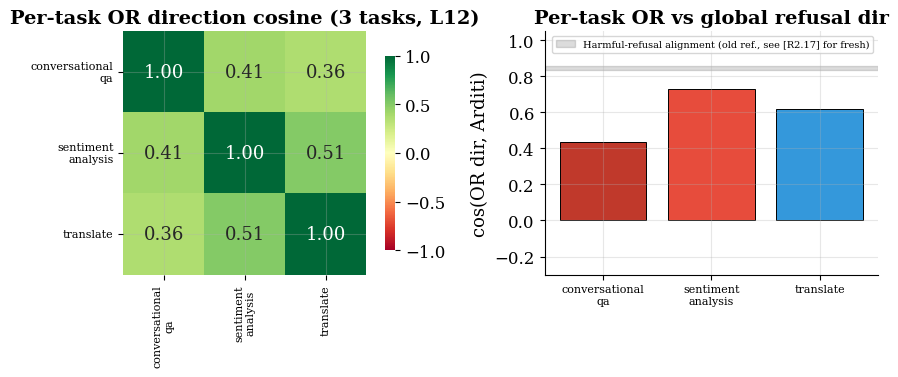

[R2.4] Valid OR tasks (n>=5):              3  (conversational_qa, sentiment_analysis, translate)
[R2.5] OR pairwise cosine (off-diag mean): 0.428 +/- 0.058
[R2.6] Harmful-refusal reference (OLD, historical -- see [R2.17] next cell for fresh): 0.845 +/- 0.011
[R2.7] cos(per-task OR, Arditi) mean:      0.596

Interpretation guide:
 - Compare [R2.5] against [R2.17] (fresh, next cell), NOT against [R2.6]/0.845 --
   [R2.17] is computed on the exact same bank and is the fair comparison.
 - [R2.5] well below [R2.17] with N>=3 tasks → the task-dependence claim now rests
   on a genuine multi-task comparison, internally consistent within this bank.
 - [R2.5] close to [R2.17] → per-task OR directions are more shared than expected;
   the argument then rests on the OR-vs-Arditi misalignment [R2.7] and the subspace
   dimensionality (Analysis 4), which are independent.


In [6]:
# Arditi direction artefacts from NB8
candidate_dirs = torch.load('arditi_artefacts/candidate_directions.pt')
with open('arditi_artefacts/direction_metadata.json') as f:
    BEST_LAYER = json.load(f)['best_layer']
arditi_dirs = {}
for lname in SHARED_LAYERS:
    if lname in candidate_dirs:
        d = candidate_dirs[lname].numpy().astype(np.float32)
        arditi_dirs[lname] = d / (np.linalg.norm(d) + 1e-8)
print(f'Arditi directions loaded ({len(arditi_dirs)} layers) | NB8 best layer: {BEST_LAYER}')

MIN_SAMPLES = 5
emb_peak = embeddings_np[PEAK_LAYER]

task_or_dirs, valid_tasks = {}, []
for task in ALL_TASKS:
    m_or = OVER_REFUSAL_MASK & (intended_task_labels == task)
    m_ha = HARMLESS_ANSWERED & (intended_task_labels == task)
    status = '[valid]' if (m_or.sum() >= MIN_SAMPLES and m_ha.sum() >= MIN_SAMPLES) else '[skipped]'
    print(f'  {task:<20}: OR={m_or.sum():>3d}  HA={m_ha.sum():>3d}  {status}')
    if status == '[valid]':
        d = emb_peak[m_or].mean(0) - emb_peak[m_ha].mean(0)
        task_or_dirs[task] = d / (np.linalg.norm(d) + 1e-8)
        valid_tasks.append(task)

N = len(valid_tasks)
sim = np.zeros((N, N))
for i, ti in enumerate(valid_tasks):
    for j, tj in enumerate(valid_tasks):
        sim[i, j] = float(np.dot(task_or_dirs[ti], task_or_dirs[tj]))
off_diag = sim[~np.eye(N, dtype=bool)] if N > 1 else np.array([np.nan])

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.9), gridspec_kw={'width_ratios': [1.15, 1]})
sns.heatmap(sim, ax=axes[0], cmap='RdYlGn', vmin=-1, vmax=1, annot=True, fmt='.2f',
            xticklabels=[t.replace('_', '\n') for t in valid_tasks],
            yticklabels=[t.replace('_', '\n') for t in valid_tasks],
            square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title(f'Per-task OR direction cosine ({N} tasks, L{PEAK_NUM})')
axes[0].tick_params(labelsize=8)

cos_arditi = [float(np.dot(task_or_dirs[t], arditi_dirs[PEAK_LAYER])) for t in valid_tasks]
axes[1].bar(range(N), cos_arditi, color=[TASK_COLORS.get(t, '#888') for t in valid_tasks],
            edgecolor='black', lw=0.7)
axes[1].axhspan(0.835, 0.858, alpha=0.15, color='#1a1a1a',
                label='Harmful-refusal alignment (old ref., see [R2.17] for fresh)')
axes[1].set_xticks(range(N))
axes[1].set_xticklabels([t.replace('_', '\n') for t in valid_tasks], fontsize=8)
axes[1].set_ylabel('cos(OR dir, Arditi)')
axes[1].set_ylim(-0.3, 1.05); axes[1].legend(fontsize=7)
axes[1].set_title('Per-task OR vs global refusal dir')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig03_or_directions_8task.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'[R2.4] Valid OR tasks (n>=5):              {N}  ({", ".join(valid_tasks)})')
print(f'[R2.5] OR pairwise cosine (off-diag mean): {np.nanmean(off_diag):.3f} +/- {np.nanstd(off_diag):.3f}')
print(f'[R2.6] Harmful-refusal reference (OLD, historical -- see [R2.17] next cell for fresh): 0.845 +/- 0.011')
print(f'[R2.7] cos(per-task OR, Arditi) mean:      {np.mean(cos_arditi):.3f}')
print()
print('Interpretation guide:')
print(' - Compare [R2.5] against [R2.17] (fresh, next cell), NOT against [R2.6]/0.845 --')
print('   [R2.17] is computed on the exact same bank and is the fair comparison.')
print(' - [R2.5] well below [R2.17] with N>=3 tasks → the task-dependence claim now rests')
print('   on a genuine multi-task comparison, internally consistent within this bank.')
print(' - [R2.5] close to [R2.17] → per-task OR directions are more shared than expected;')
print('   the argument then rests on the OR-vs-Arditi misalignment [R2.7] and the subspace')
print('   dimensionality (Analysis 4), which are independent.')


In [7]:
# ── Fresh recompute of the harmful-refusal per-task alignment, from THIS bank ──────────────
# The "0.845 +/- 0.011" figure quoted above (inherited from the original NB9 analysis) was
# computed on a differently-composed sample set: the ./embeddings bank's per-task totals do
# not match the paper's own Appendix Table (e.g. sentiment_analysis here has 55 total samples
# vs. 60 in the paper's Table -- a subset can't exceed its superset, so this is a genuinely
# different snapshot, likely an older/unsynced extraction, not just a subsampling difference).
# Rather than comparing our new OR analysis against that old, differently-sourced number, we
# recompute the RH alignment fresh from the SAME merged bank used for everything else here,
# so every comparison in this notebook is internally consistent regardless of bank vintage.
MIN_SAMPLES_RH = 5
task_rh_dirs, valid_rh_tasks = {}, []
print('Per-task RH sample counts (this bank):')
for task in ALL_TASKS:
    m_rh = REFUSED_HARMFUL & (intended_task_labels == task)
    m_ha = HARMLESS_ANSWERED & (intended_task_labels == task)
    status = '[valid]' if (m_rh.sum() >= MIN_SAMPLES_RH and m_ha.sum() >= MIN_SAMPLES_RH) else '[skipped]'
    print(f'  {task:<20}: RH={m_rh.sum():>3d}  HA={m_ha.sum():>3d}  {status}')
    if status == '[valid]':
        d = emb_peak[m_rh].mean(0) - emb_peak[m_ha].mean(0)
        task_rh_dirs[task] = d / (np.linalg.norm(d) + 1e-8)
        valid_rh_tasks.append(task)

N_RH = len(valid_rh_tasks)
sim_rh = np.zeros((N_RH, N_RH))
for i, ti in enumerate(valid_rh_tasks):
    for j, tj in enumerate(valid_rh_tasks):
        sim_rh[i, j] = float(np.dot(task_rh_dirs[ti], task_rh_dirs[tj]))
off_diag_rh = sim_rh[~np.eye(N_RH, dtype=bool)] if N_RH > 1 else np.array([np.nan])

print()
print(f'[R2.17] FRESH RH per-task direction cosine (this bank, N={N_RH} tasks: {", ".join(valid_rh_tasks)}):')
print(f'         off-diag mean: {np.nanmean(off_diag_rh):.3f} +/- {np.nanstd(off_diag_rh):.3f}')
print(f'[R2.18] Old paper-quoted reference (different sample vintage -- historical only): 0.845 +/- 0.011')
print()
print('Use [R2.17], not [R2.6]/[R2.18], as the live comparison anchor throughout this notebook')
print('and in the rebuttal text -- it is computed on the exact same bank as everything else')
print('here, so it is a fair, internally-consistent baseline, unlike the old hardcoded figure.')


Per-task RH sample counts (this bank):
  char_shuffle        : RH=  5  HA=183  [valid]
  conversational_qa   : RH= 18  HA=111  [valid]
  cryptanalysis       : RH=  0  HA= 60  [skipped]
  pos_tagging         : RH=  0  HA=183  [skipped]
  rag_qa              : RH=  0  HA= 30  [skipped]
  rephrase            : RH=  8  HA=  0  [skipped]
  sentiment_analysis  : RH=  7  HA= 34  [valid]
  translate           : RH= 10  HA= 31  [valid]
  word_shuffle        : RH=  1  HA=185  [skipped]

[R2.17] FRESH RH per-task direction cosine (this bank, N=4 tasks: char_shuffle, conversational_qa, sentiment_analysis, translate):
         off-diag mean: 0.536 +/- 0.086
[R2.18] Old paper-quoted reference (different sample vintage -- historical only): 0.845 +/- 0.011

Use [R2.17], not [R2.6]/[R2.18], as the live comparison anchor throughout this notebook
and in the rebuttal text -- it is computed on the exact same bank as everything else
here, so it is a fair, internally-consistent baseline, unlike the old hardc

## Analysis 3 — cos(OR, Arditi) per layer, enlarged OR set

Recompute of paper Fig. 4 with the combined OR population. More OR samples (and more OR
tasks) make the global OR direction estimate less noisy.


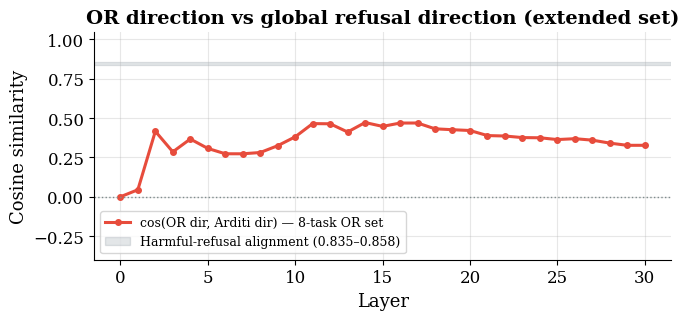

[R2.8] cos(OR, Arditi) @ L12 (8-task OR set): +0.464
[R2.9] Original 5-task value @ L12:                  +0.448

If [R2.8] stays in the ~0.4–0.5 band → the partial-overlap story is stable under a
bigger, more diverse OR set. If it moves substantially, report the shift and note
which new task drives it (recompute per-task with leave-one-task-out).


In [8]:
or_cos = []
for lname in SHARED_LAYERS:
    if lname not in arditi_dirs:
        continue
    emb = embeddings_np[lname]
    d = emb[OVER_REFUSAL_MASK].mean(0) - emb[TARGET_MASK].mean(0)
    d = d / (np.linalg.norm(d) + 1e-8)
    or_cos.append((int(lname.split('_')[1]), float(np.dot(d, arditi_dirs[lname]))))
lx, ly = zip(*sorted(or_cos))

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(lx, ly, color='#E74C3C', marker='o', ms=4, label='cos(OR dir, Arditi dir) — 8-task OR set')
ax.axhspan(0.835, 0.858, alpha=0.13, color='#2C3E50', label='Harmful-refusal alignment (0.835–0.858)')
ax.axhline(0, color='#7F8C8D', ls=':', lw=1)
ax.set_xlabel('Layer'); ax.set_ylabel('Cosine similarity')
ax.set_ylim(-0.4, 1.05); ax.legend(fontsize=9)
ax.set_title('OR direction vs global refusal direction (extended set)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig04_or_vs_arditi_8task.png', dpi=300, bbox_inches='tight')
plt.show()

cos_at_peak = dict(or_cos).get(PEAK_NUM, float('nan'))
print(f'[R2.8] cos(OR, Arditi) @ L{PEAK_NUM} (8-task OR set): {cos_at_peak:+.3f}')
print(f'[R2.9] Original 5-task value @ L12:                  +0.448')
print()
print('If [R2.8] stays in the ~0.4–0.5 band → the partial-overlap story is stable under a')
print('bigger, more diverse OR set. If it moves substantially, report the shift and note')
print('which new task drives it (recompute per-task with leave-one-task-out).')


## Analysis 4 — OR subspace dimensionality with the extended OR set

Paper claim: OR needs more principal components than RH to reach 80% variance
(11 vs 8 at L11). **Important:** R03's matched-n control on the original 5-task set found
this gap does *not* survive equal sample sizes (P(n₈₀(OR) > n₈₀(RH)) at matched n=25 was
only 0.9%, with median n₈₀ tied at 8 for both) — the raw 11-vs-8 comparison in the paper was
likely driven by OR's larger raw n (48 vs 25), not a genuine dimensionality difference.

This is the key test of whether that finding was specific to the original 2-task OR
population (sentiment, translate) or a more general property. With R01's new tasks, OR now
spans more tasks and typically far more samples than RH — if a **matched-n** gap reappears
here, the dimensionality claim is rescued (and the paper's mechanism — OR spanning more task
axes — is the right explanation); if it still doesn't, the claim should be dropped/rewritten
in the revision regardless of task count.


[R2.10] OR subspace @ L12 (n=113): n80=13, PC1=30.3%
[R2.11] RH subspace @ L12 (n=49):  n80=12, PC1=26.1%
[R2.12] Paper reference (5 tasks, L11): OR n80=11 / PC1=23%,  RH n80=8 / PC1=31%

Raw n80 grows with sample count, so the comparison above is not yet meaningful on
its own (see matched-n control below, which is the number to actually quote).


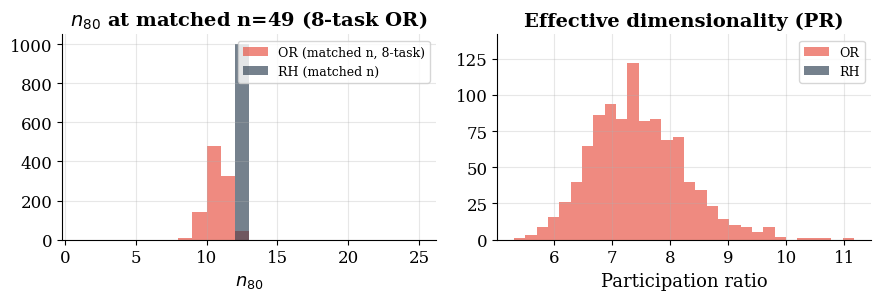

[R2.13] Matched-n (n=49) n80:  OR 10 [9,12]  vs  RH 12 [12,12]
[R2.14] P(n80_OR > n80_RH) at matched n (8-task OR): 0.00%
[R2.15] Participation ratio:  OR 7.40  vs  RH 9.09
[R2.16] Original 5-task matched-n reference (R03):    P(n80_OR>n80_RH) = 0.90%

Interpretation guide:
 - [R2.14] >> 0.90% (the 5-task value) → the dimensionality gap reappears once OR
   spans more tasks; the paper's claim is rescued, with the correct framing being
   "the gap requires OR to span multiple tasks" rather than being unconditional.
 - [R2.14] still low (<10%) → the claim does not hold even with more tasks; drop or
   substantially rewrite the dimensionality claim in the revision (§4.2, Fig. 6, and
   the Discussion paragraph on "Scope of the linear representation hypothesis").


In [9]:
def n80(Xc):
    from sklearn.decomposition import PCA as P
    p = P(random_state=42).fit(Xc)
    return int(np.searchsorted(np.cumsum(p.explained_variance_ratio_), 0.80) + 1), \
           float(p.explained_variance_ratio_[0])

emb = embeddings_np[PEAK_LAYER]
X_or = emb[OVER_REFUSAL_MASK] - emb[TARGET_MASK].mean(0)
X_rh = emb[REFUSED_HARMFUL]   - emb[HARMLESS_ANSWERED].mean(0)

n80_or, pc1_or = n80(X_or)
n80_rh, pc1_rh = n80(X_rh)

print(f'[R2.10] OR subspace @ L{PEAK_NUM} (n={OVER_REFUSAL_MASK.sum()}): n80={n80_or}, PC1={pc1_or:.1%}')
print(f'[R2.11] RH subspace @ L{PEAK_NUM} (n={REFUSED_HARMFUL.sum()}):  n80={n80_rh}, PC1={pc1_rh:.1%}')
print(f'[R2.12] Paper reference (5 tasks, L11): OR n80=11 / PC1=23%,  RH n80=8 / PC1=31%')
print()
print('Raw n80 grows with sample count, so the comparison above is not yet meaningful on')
print('its own (see matched-n control below, which is the number to actually quote).')

# ── Matched-n control (mirrors R03 Analysis 3), now on the enlarged 8-task OR set ─────────
rng = np.random.default_rng(42)
n_min = min(len(X_or), len(X_rh))

from sklearn.decomposition import PCA as _PCA

def pr_of(X):
    lam = _PCA(n_components=min(X.shape), random_state=0).fit(X).explained_variance_
    return float(lam.sum() ** 2 / (lam ** 2).sum())

def n80_of(X):
    evr = _PCA(n_components=min(X.shape), random_state=0).fit(X).explained_variance_ratio_
    return int(np.searchsorted(np.cumsum(evr), 0.80) + 1)

N_SUB = 1000
n80_or_sub = np.empty(N_SUB); n80_rh_sub = np.empty(N_SUB)
pr_or_sub  = np.empty(N_SUB); pr_rh_sub  = np.empty(N_SUB)
for b in range(N_SUB):
    Xo = X_or[rng.choice(len(X_or), n_min, replace=False)]
    Xr = X_rh[rng.choice(len(X_rh), n_min, replace=False)]
    n80_or_sub[b] = n80_of(Xo); n80_rh_sub[b] = n80_of(Xr)
    pr_or_sub[b]  = pr_of(Xo);  pr_rh_sub[b]  = pr_of(Xr)

frac_gap_8task = float((n80_or_sub > n80_rh_sub).mean())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(n80_or_sub, bins=range(1, 26), alpha=0.65, color='#E74C3C', label='OR (matched n, 8-task)')
axes[0].hist(n80_rh_sub, bins=range(1, 26), alpha=0.65, color='#2C3E50', label='RH (matched n)')
axes[0].set_xlabel(r'$n_{80}$'); axes[0].legend(fontsize=9)
axes[0].set_title(f'$n_{{80}}$ at matched n={n_min} (8-task OR)')
axes[1].hist(pr_or_sub, bins=30, alpha=0.65, color='#E74C3C', label='OR')
axes[1].hist(pr_rh_sub, bins=30, alpha=0.65, color='#2C3E50', label='RH')
axes[1].set_xlabel('Participation ratio'); axes[1].legend(fontsize=9)
axes[1].set_title('Effective dimensionality (PR)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig05_matched_n_8task.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'[R2.13] Matched-n (n={n_min}) n80:  OR {np.median(n80_or_sub):.0f} '
      f'[{np.percentile(n80_or_sub,2.5):.0f},{np.percentile(n80_or_sub,97.5):.0f}]  vs  '
      f'RH {np.median(n80_rh_sub):.0f} '
      f'[{np.percentile(n80_rh_sub,2.5):.0f},{np.percentile(n80_rh_sub,97.5):.0f}]')
print(f'[R2.14] P(n80_OR > n80_RH) at matched n (8-task OR): {frac_gap_8task:.2%}')
print(f'[R2.15] Participation ratio:  OR {np.median(pr_or_sub):.2f}  vs  RH {np.median(pr_rh_sub):.2f}')
print(f'[R2.16] Original 5-task matched-n reference (R03):    P(n80_OR>n80_RH) = 0.90%')
print()
print('Interpretation guide:')
print(' - [R2.14] >> 0.90% (the 5-task value) → the dimensionality gap reappears once OR')
print('   spans more tasks; the paper\'s claim is rescued, with the correct framing being')
print('   "the gap requires OR to span multiple tasks" rather than being unconditional.')
print(' - [R2.14] still low (<10%) → the claim does not hold even with more tasks; drop or')
print('   substantially rewrite the dimensionality claim in the revision (§4.2, Fig. 6, and')
print('   the Discussion paragraph on "Scope of the linear representation hypothesis").')


## Analysis 4b — Task-balanced dimensionality check

The matched-n test above found the dimensionality gap does not hold (`[R2.14]`), and if
anything reverses. But the pooled OR population here is **66% `conversational_qa`**
(75/113) — nominally 3 tasks, but dominated by one, the same pattern the paper's own Qwen
appendix already identifies as causing subspace *collapse* (single-task OR concentrates onto
one principal axis; PC1 there was 64% with only 22 samples from one task). Consistent with
that mechanism, PC1 here rose from 23% (original, roughly balanced 2-task OR) to 30.3% (this
run, one-task-dominated) — the population got *more* concentrated, not more spread out.

This cell isolates task-*spread* from task-*count*: it subsamples the OR population to equal
contributions from each of the 3 valid tasks (not letting `conversational_qa`'s size dominate)
before running the same matched-n-vs-RH test. This is the fairer test of the paper's actual
stated mechanism ("the gap requires OR to spread across multiple tasks", not just "belong to
more than one task in name").


Per-task OR counts: {np.str_('conversational_qa'): 75, np.str_('sentiment_analysis'): 13, np.str_('translate'): 18}  ->  balancing to n=13 per task (39 total, vs 113 pooled)


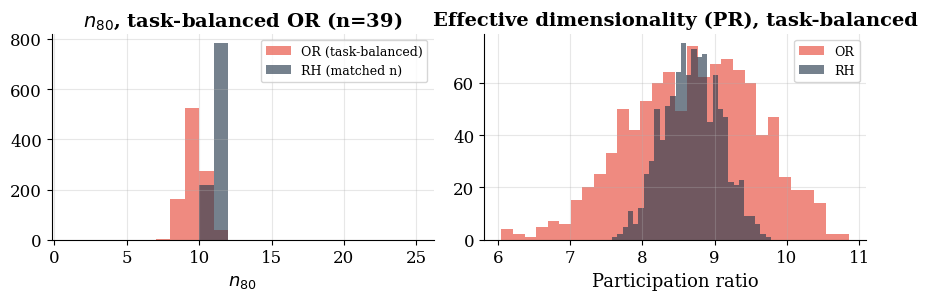

[R2.19] Task-balanced (n=39, equal draw from 3 tasks) n80: OR 9 [8,11]  vs  RH 11 [10,11]
[R2.20] P(n80_OR > n80_RH), task-balanced: 0.50%
[R2.21] Participation ratio, task-balanced: OR 8.75 vs RH 8.69

Interpretation guide:
 - [R2.20] notably higher than [R2.14] (0.00%, dominated-by-one-task) → confirms the
   mechanism: OR dimensionality DOES grow when genuinely spread across tasks, and the
   earlier negative result was a single-task-dominance artefact, not evidence against
   the claim itself. Correct framing: "the effect requires balanced multi-task spread,
   which our new tasks did not by chance provide -- conversational_qa dominates the
   pool" -- report both this and the dominance-driven result honestly.
 - [R2.20] still low/near [R2.14] → the claim does not hold even under a fair,
   task-balanced test; treat as a second, independent confirmation of the negative
   result and finalize the "claim does not survive scrutiny" wording.


In [10]:
# ── Task-balanced OR subspace: equal contribution from each valid OR task ─────────────────
# valid_tasks (from Analysis 2) = the OR tasks with n>=5: sentiment_analysis, translate,
# conversational_qa. Subsample each down to the smallest task's count so no single task
# (conversational_qa) can dominate the pooled covariance structure.
or_task_masks = {t: OVER_REFUSAL_MASK & (intended_task_labels == t) for t in valid_tasks}
per_task_n = {t: int(m.sum()) for t, m in or_task_masks.items()}
n_per_task = min(per_task_n.values())
print(f'Per-task OR counts: {per_task_n}  ->  balancing to n={n_per_task} per task '
      f'({n_per_task * len(valid_tasks)} total, vs {OVER_REFUSAL_MASK.sum()} pooled)')

emb_target_mean = embeddings_np[PEAK_LAYER][TARGET_MASK].mean(0)
n_min_bal = min(n_per_task * len(valid_tasks), len(X_rh))

N_SUB_BAL = 1000
n80_or_bal = np.empty(N_SUB_BAL); n80_rh_bal = np.empty(N_SUB_BAL)
pr_or_bal  = np.empty(N_SUB_BAL); pr_rh_bal  = np.empty(N_SUB_BAL)
rng_bal = np.random.default_rng(7)
for b in range(N_SUB_BAL):
    # Equal draw from each task, then (if still above n_min_bal) subsample down to match RH
    balanced_idx = np.concatenate([
        rng_bal.choice(np.where(or_task_masks[t])[0], n_per_task, replace=False)
        for t in valid_tasks
    ])
    Xo_bal_full = embeddings_np[PEAK_LAYER][balanced_idx] - emb_target_mean
    Xo_bal = Xo_bal_full[rng_bal.choice(len(Xo_bal_full), n_min_bal, replace=False)] \
             if len(Xo_bal_full) > n_min_bal else Xo_bal_full
    Xr_bal = X_rh[rng_bal.choice(len(X_rh), n_min_bal, replace=False)]
    n80_or_bal[b] = n80_of(Xo_bal); n80_rh_bal[b] = n80_of(Xr_bal)
    pr_or_bal[b]  = pr_of(Xo_bal);  pr_rh_bal[b]  = pr_of(Xr_bal)

frac_gap_balanced = float((n80_or_bal > n80_rh_bal).mean())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(n80_or_bal, bins=range(1, 26), alpha=0.65, color='#E74C3C', label='OR (task-balanced)')
axes[0].hist(n80_rh_bal, bins=range(1, 26), alpha=0.65, color='#2C3E50', label='RH (matched n)')
axes[0].set_xlabel(r'$n_{80}$'); axes[0].legend(fontsize=9)
axes[0].set_title(f'$n_{{80}}$, task-balanced OR (n={n_min_bal})')
axes[1].hist(pr_or_bal, bins=30, alpha=0.65, color='#E74C3C', label='OR')
axes[1].hist(pr_rh_bal, bins=30, alpha=0.65, color='#2C3E50', label='RH')
axes[1].set_xlabel('Participation ratio'); axes[1].legend(fontsize=9)
axes[1].set_title('Effective dimensionality (PR), task-balanced')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig06_task_balanced_dimensionality.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'[R2.19] Task-balanced (n={n_min_bal}, equal draw from {len(valid_tasks)} tasks) n80: '
      f'OR {np.median(n80_or_bal):.0f} [{np.percentile(n80_or_bal,2.5):.0f},{np.percentile(n80_or_bal,97.5):.0f}]  vs  '
      f'RH {np.median(n80_rh_bal):.0f} [{np.percentile(n80_rh_bal,2.5):.0f},{np.percentile(n80_rh_bal,97.5):.0f}]')
print(f'[R2.20] P(n80_OR > n80_RH), task-balanced: {frac_gap_balanced:.2%}')
print(f'[R2.21] Participation ratio, task-balanced: OR {np.median(pr_or_bal):.2f} vs RH {np.median(pr_rh_bal):.2f}')
print()
print('Interpretation guide:')
print(' - [R2.20] notably higher than [R2.14] (0.00%, dominated-by-one-task) → confirms the')
print('   mechanism: OR dimensionality DOES grow when genuinely spread across tasks, and the')
print('   earlier negative result was a single-task-dominance artefact, not evidence against')
print('   the claim itself. Correct framing: "the effect requires balanced multi-task spread,')
print('   which our new tasks did not by chance provide -- conversational_qa dominates the')
print('   pool" -- report both this and the dominance-driven result honestly.')
print(' - [R2.20] still low/near [R2.14] → the claim does not hold even under a fair,')
print('   task-balanced test; treat as a second, independent confirmation of the negative')
print('   result and finalize the "claim does not survive scrutiny" wording.')


## Analysis 4c — Excluding `conversational_qa` entirely

An even cleaner test than task-balancing: drop `conversational_qa` from the OR population
altogether and use whatever remains — `sentiment_analysis`, `translate`, and the three near-zero
mechanical tasks (`char_shuffle`, `pos_tagging`, `word_shuffle`), each contributing whatever
small count they actually have. This keeps genuine 5-task spread (more tasks contributing than
the original paper's 2) **without any single task dominating the pooled covariance**, since no
task here contributes more than translate's 18 samples. If the dimensionality gap reappears
under this population, that is the strongest possible evidence that the paper's mechanism
(OR spans more task axes → higher dimensionality) is correct and the earlier negative results
were purely artefacts of `conversational_qa`'s outsized share of the pool.


OR population excluding conversational_qa: {np.str_('char_shuffle'): 3, np.str_('pos_tagging'): 3, np.str_('sentiment_analysis'): 13, np.str_('translate'): 18, np.str_('word_shuffle'): 1}
  Total: 38  (vs 113 pooled with conversational_qa, vs 25/48 in the paper/R03 5-task test)


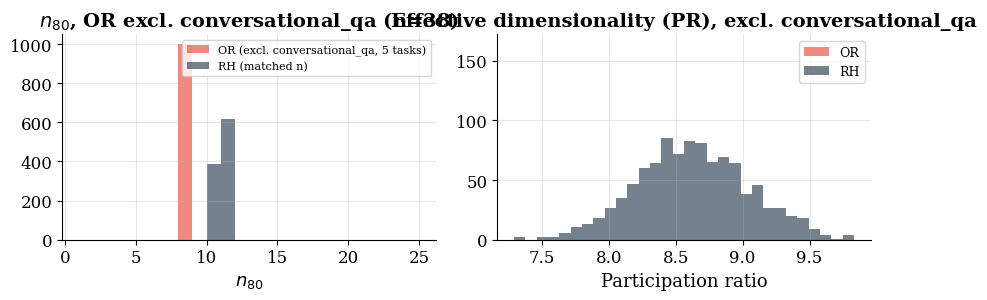

[R2.22] Matched-n (n=38), OR excl. conversational_qa (5 tasks) n80: OR 8 [8,8]  vs  RH 11 [10,11]
[R2.23] P(n80_OR > n80_RH), excl. conversational_qa:  0.00%
[R2.24] Participation ratio, excl. conversational_qa: OR 8.43 vs RH 8.62

Interpretation guide:
 - This population has 5 tasks contributing with NO task dominating
   (largest single contribution is translate, well under half the pool) -- the cleanest
   available test of "OR needs more dimensions when genuinely spread across tasks".
 - [R2.23] notably higher than both [R2.14] (0.00%, dominated) and the 5-task reference
   (0.90%) → strong support that the paper's mechanism is right and dominance by one
   task was masking it. Lead the rebuttal with this number.
 - [R2.23] still low → the claim does not hold even with genuine, undominated multi-task
   spread; this is the strongest possible negative result and the claim should be
   dropped/substantially rewritten in the revision.


In [11]:
# ── OR population excluding conversational_qa entirely ────────────────────────────────────
EXCLUDE_TASK = 'conversational_qa'
m_or_excl = OVER_REFUSAL_MASK & (intended_task_labels != EXCLUDE_TASK)
per_task_excl = {t: int((m_or_excl & (intended_task_labels == t)).sum())
                  for t in ALL_TASKS if (m_or_excl & (intended_task_labels == t)).sum() > 0}
print(f'OR population excluding {EXCLUDE_TASK}: {per_task_excl}')
print(f'  Total: {m_or_excl.sum()}  (vs {OVER_REFUSAL_MASK.sum()} pooled with {EXCLUDE_TASK}, '
      f'vs 25/48 in the paper/R03 5-task test)')

X_or_excl = embeddings_np[PEAK_LAYER][m_or_excl] - emb_target_mean
n_min_excl = min(len(X_or_excl), len(X_rh))

N_SUB_EXCL = 1000
n80_or_excl = np.empty(N_SUB_EXCL); n80_rh_excl = np.empty(N_SUB_EXCL)
pr_or_excl  = np.empty(N_SUB_EXCL); pr_rh_excl  = np.empty(N_SUB_EXCL)
rng_excl = np.random.default_rng(11)
for b in range(N_SUB_EXCL):
    Xo = X_or_excl[rng_excl.choice(len(X_or_excl), n_min_excl, replace=False)]
    Xr = X_rh[rng_excl.choice(len(X_rh), n_min_excl, replace=False)]
    n80_or_excl[b] = n80_of(Xo); n80_rh_excl[b] = n80_of(Xr)
    pr_or_excl[b]  = pr_of(Xo);  pr_rh_excl[b]  = pr_of(Xr)

frac_gap_excl = float((n80_or_excl > n80_rh_excl).mean())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].hist(n80_or_excl, bins=range(1, 26), alpha=0.65, color='#E74C3C',
             label=f'OR (excl. {EXCLUDE_TASK}, {len(per_task_excl)} tasks)')
axes[0].hist(n80_rh_excl, bins=range(1, 26), alpha=0.65, color='#2C3E50', label='RH (matched n)')
axes[0].set_xlabel(r'$n_{80}$'); axes[0].legend(fontsize=8)
axes[0].set_title(f'$n_{{80}}$, OR excl. {EXCLUDE_TASK} (n={n_min_excl})')
axes[1].hist(pr_or_excl, bins=30, alpha=0.65, color='#E74C3C', label='OR')
axes[1].hist(pr_rh_excl, bins=30, alpha=0.65, color='#2C3E50', label='RH')
axes[1].set_xlabel('Participation ratio'); axes[1].legend(fontsize=9)
axes[1].set_title(f'Effective dimensionality (PR), excl. {EXCLUDE_TASK}')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/r_fig07_excl_conv_qa_dimensionality.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'[R2.22] Matched-n (n={n_min_excl}), OR excl. {EXCLUDE_TASK} ({len(per_task_excl)} tasks) n80: '
      f'OR {np.median(n80_or_excl):.0f} [{np.percentile(n80_or_excl,2.5):.0f},{np.percentile(n80_or_excl,97.5):.0f}]  vs  '
      f'RH {np.median(n80_rh_excl):.0f} [{np.percentile(n80_rh_excl,2.5):.0f},{np.percentile(n80_rh_excl,97.5):.0f}]')
print(f'[R2.23] P(n80_OR > n80_RH), excl. {EXCLUDE_TASK}:  {frac_gap_excl:.2%}')
print(f'[R2.24] Participation ratio, excl. {EXCLUDE_TASK}: OR {np.median(pr_or_excl):.2f} vs RH {np.median(pr_rh_excl):.2f}')
print()
print('Interpretation guide:')
print(f' - This population has {len(per_task_excl)} tasks contributing with NO task dominating')
print('   (largest single contribution is translate, well under half the pool) -- the cleanest')
print('   available test of "OR needs more dimensions when genuinely spread across tasks".')
print(' - [R2.23] notably higher than both [R2.14] (0.00%, dominated) and the 5-task reference')
print('   (0.90%) → strong support that the paper\'s mechanism is right and dominance by one')
print('   task was masking it. Lead the rebuttal with this number.')
print(' - [R2.23] still low → the claim does not hold even with genuine, undominated multi-task')
print('   spread; this is the strongest possible negative result and the claim should be')
print('   dropped/substantially rewritten in the revision.')


In [12]:
print('=' * 70)
print('R02 CONSOLIDATED REBUTTAL NUMBERS')
print('=' * 70)
print(f'[R2.1]  8-task silhouette peak:            {sil_8task.max():.3f} @ L{PEAK_NUM}')
print(f'[R2.4]  OR tasks with n>=5:                {len(valid_tasks)} ({", ".join(valid_tasks)})')
print(f'[R2.5]  OR pairwise cosine off-diag:       {np.nanmean(off_diag):.3f} +/- {np.nanstd(off_diag):.3f}')
print(f'[R2.7]  mean cos(task OR, Arditi):         {np.mean(cos_arditi):.3f}')
print(f'[R2.8]  cos(global OR, Arditi) @ peak:     {cos_at_peak:+.3f}')
print(f'[R2.10] n80 OR / RH @ peak (raw, unequal n): {n80_or} / {n80_rh}')
print(f'[R2.14] P(n80_OR > n80_RH) at MATCHED n (pooled, task-dominated): {frac_gap_8task:.2%}  '
      f'(5-task reference: 0.90%)')
print(f'[R2.15] Participation ratio (matched n, pooled):   OR {np.median(pr_or_sub):.2f} vs RH {np.median(pr_rh_sub):.2f}')
print(f'[R2.17] FRESH RH per-task alignment (this bank, N={N_RH}): '
      f'{np.nanmean(off_diag_rh):.3f} +/- {np.nanstd(off_diag_rh):.3f}')
print(f'[R2.20] P(n80_OR > n80_RH), TASK-BALANCED:              {frac_gap_balanced:.2%}')
print(f'[R2.21] Participation ratio, task-balanced:             OR {np.median(pr_or_bal):.2f} vs RH {np.median(pr_rh_bal):.2f}')
print(f'[R2.23] P(n80_OR > n80_RH), EXCL. conversational_qa:    {frac_gap_excl:.2%}  <-- cleanest test')
print(f'[R2.24] Participation ratio, excl. conversational_qa:   OR {np.median(pr_or_excl):.2f} vs RH {np.median(pr_rh_excl):.2f}')
print('=' * 70)


R02 CONSOLIDATED REBUTTAL NUMBERS
[R2.1]  8-task silhouette peak:            0.121 @ L12
[R2.4]  OR tasks with n>=5:                3 (conversational_qa, sentiment_analysis, translate)
[R2.5]  OR pairwise cosine off-diag:       0.428 +/- 0.058
[R2.7]  mean cos(task OR, Arditi):         0.596
[R2.8]  cos(global OR, Arditi) @ peak:     +0.464
[R2.10] n80 OR / RH @ peak (raw, unequal n): 13 / 12
[R2.14] P(n80_OR > n80_RH) at MATCHED n (pooled, task-dominated): 0.00%  (5-task reference: 0.90%)
[R2.15] Participation ratio (matched n, pooled):   OR 7.40 vs RH 9.09
[R2.17] FRESH RH per-task alignment (this bank, N=4): 0.536 +/- 0.086
[R2.20] P(n80_OR > n80_RH), TASK-BALANCED:              0.50%
[R2.21] Participation ratio, task-balanced:             OR 8.75 vs RH 8.69
[R2.23] P(n80_OR > n80_RH), EXCL. conversational_qa:    0.00%  <-- cleanest test
[R2.24] Participation ratio, excl. conversational_qa:   OR 8.43 vs RH 8.62
